In [ ]:
# =========================================================
# 1. IMPORT
# =========================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import math

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import VarianceThreshold, SelectKBest, mutual_info_classif
from sklearn.decomposition import PCA

from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

pd.set_option('display.max_columns', None)

# =========================================================
# 2. LOAD DATA
# =========================================================
file_id = '1rTFaaNhlieVoe08twl_kQltsxnpc7Qa8'
url = f'https://drive.google.com/uc?id={file_id}'
df = pd.read_csv(url)

print("="*60)
print("THÔNG TIN DỮ LIỆU BAN ĐẦU")
print("="*60)
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\n5 dòng đầu:")
print(df.head())

# =========================================================
# 3. XỬ LÝ NHÃN + DROP
# =========================================================
df['num'] = df['num'].apply(lambda x: 1 if x > 0 else 0)
df = df.drop(columns=['id', 'dataset'], errors='ignore')

# =========================================================
# 4. KHÁM PHÁ DỮ LIỆU (EDA) 
# =========================================================
print("\n" + "="*60)
print("EDA - KHÁM PHÁ VÀ THỐNG KÊ DỮ LIỆU")
print("="*60)

# 4.1. Thống kê mô tả
eda_summary = df.describe().T
print(eda_summary)
eda_summary.to_csv('eda_summary_statistics.csv')

# Tạo thư mục lưu hình EDA
if not os.path.exists("eda_plots"):
    os.makedirs("eda_plots")

# 4.2. Vẽ phân bố Target
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='num', palette='Set2')
plt.title("Phân bố biến mục tiêu (Target Distribution)")
plt.savefig("eda_plots/1_target_distribution.png")
plt.close()

# Tách riêng cột số để vẽ đồ thị
numeric_cols_eda = df.select_dtypes(include=[np.number]).columns.drop('num', errors='ignore')
n_cols = len(numeric_cols_eda)
cols_plot = 4
rows_plot = math.ceil(n_cols / cols_plot)

# 4.3. Vẽ Boxplot kiểm tra Outlier
plt.figure(figsize=(15, rows_plot * 3))
for i, col in enumerate(numeric_cols_eda, 1):
    plt.subplot(rows_plot, cols_plot, i)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(f"Boxplot: {col}")
    plt.tight_layout()
plt.savefig("eda_plots/2_numeric_boxplots.png")
plt.close()

# 4.4. Vẽ Histogram kiểm tra phân phối (Skewness)
plt.figure(figsize=(15, rows_plot * 3))
for i, col in enumerate(numeric_cols_eda, 1):
    plt.subplot(rows_plot, cols_plot, i)
    sns.histplot(df[col], kde=True, color='salmon')
    plt.title(f"Histogram: {col}")
    plt.tight_layout()
plt.savefig("eda_plots/3_numeric_histograms.png")
plt.close()

print("\nĐã xuất các bảng thống kê và biểu đồ EDA vào thư mục 'eda_plots/'!")

# =========================================================
# 5. KIỂM TRA MISSING
# =========================================================
print("\n" + "="*60)
print("MISSING VALUES")
print("="*60)

missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing': missing,
    'Percent': missing_percent
})

print(missing_df[missing_df['Missing'] > 0])

# =========================================================
# 6. LỌC TƯƠNG QUAN
# =========================================================
numeric_cols = df.drop(columns=['num']).select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr().abs()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, cmap='RdBu_r')
plt.title("Correlation Heatmap")
plt.savefig("eda_plots/4_correlation_heatmap.png")
plt.close()

upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [col for col in upper_tri.columns if any(upper_tri[col] > 0.9)]

df = df.drop(columns=to_drop)

print("\nCORRELATION FILTER")
print("Drop:", to_drop if len(to_drop) > 0 else "Không có")

# =========================================================
# 7. TÁCH X, y
# =========================================================
X = df.drop(columns=['num'])
y = df['num']

# =========================================================
# 8. CHIA TRAIN / TEST
# =========================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("\nTRAIN TEST SPLIT")
print("Train:", X_train.shape)
print("Test:", X_test.shape)

# =========================================================
# 9. XÁC ĐỊNH FEATURE TYPE
# =========================================================
numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

# =========================================================
# 10. PIPELINE TIỀN XỬ LÝ
# =========================================================
numeric_transformer = Pipeline([
    ('imputer', KNNImputer(n_neighbors=5)),
    ('scaler', RobustScaler()),
    ('variance', VarianceThreshold(0.01))
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

# =========================================================
# 11. TRANSFORM DATA
# =========================================================
preprocessor.fit(X_train)

X_train_pre = preprocessor.transform(X_train)
X_test_pre = preprocessor.transform(X_test)
feature_names = preprocessor.get_feature_names_out()

# =========================================================
# 12. CÂN BẰNG DỮ LIỆU (SMOTE)
# =========================================================
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_pre, y_train)

# =========================================================
# 13. FEATURE SELECTION
# =========================================================
k = min(15, len(feature_names))

selector = SelectKBest(score_func=mutual_info_classif, k=k)
np.random.seed(42)
X_train_final = selector.fit_transform(X_train_bal, y_train_bal)
X_test_final = selector.transform(X_test_pre)

mask = selector.get_support()
selected_features = feature_names[mask]

feature_score_df = pd.DataFrame({
    'Feature': feature_names,
    'Score': selector.scores_
}).sort_values(by='Score', ascending=False)

print("\n" + "="*60)
print("TOP 10 FEATURE ĐƯỢC CHỌN")
print("="*60)
print(feature_score_df.head(10))

# =========================================================
# 14. DATAFRAME
# =========================================================
df_train_cleaned = pd.DataFrame(X_train_final, columns=selected_features)
df_train_cleaned['target'] = y_train_bal.values

df_test_cleaned = pd.DataFrame(X_test_final, columns=selected_features)
df_test_cleaned['target'] = y_test.values

# =========================================================
# 15. SO SÁNH TRƯỚC VÀ SAU XỬ LÝ
# =========================================================
print("\n" + "="*60)
print("SO SÁNH DỮ LIỆU TRƯỚC & SAU XỬ LÝ")
print("="*60)

# 15.1 So sánh nhãn Target trước và sau SMOTE
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(x=y_train, ax=axes[0], palette='Set2')
axes[0].set_title('Mất cân bằng Target (Trước SMOTE)')
sns.countplot(x=y_train_bal, ax=axes[1], palette='Set2')
axes[1].set_title('Cân bằng Target (Sau SMOTE)')
plt.tight_layout()
plt.savefig('eda_plots/5_target_before_after_smote.png')
plt.close()

# 15.2 Vẽ biểu đồ không gian PCA so sánh cấu trúc dữ liệu
pca = PCA(n_components=2, random_state=42)
# Khớp (Fit) PCA trên dữ liệu TRƯỚC SMOTE
X_pca_before = pca.fit_transform(X_train_pre)
# Biến đổi (Transform) dữ liệu SAU SMOTE dựa trên cùng hệ trục tọa độ
X_pca_after = pca.transform(X_train_bal)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Đồ thị trước SMOTE
scatter_before = axes[0].scatter(X_pca_before[:, 0], X_pca_before[:, 1], c=y_train,
                                 cmap='coolwarm', alpha=0.6, edgecolors='k')
axes[0].set_title('Không gian Dữ liệu TRƯỚC SMOTE (PCA 2D)', fontsize=14)
axes[0].set_xlabel('Thành phần chính 1')
axes[0].set_ylabel('Thành phần chính 2')

# Đồ thị sau SMOTE
scatter_after = axes[1].scatter(X_pca_after[:, 0], X_pca_after[:, 1], c=y_train_bal,
                                cmap='coolwarm', alpha=0.6, edgecolors='k')
axes[1].set_title('Không gian Dữ liệu SAU SMOTE (PCA 2D)', fontsize=14)
axes[1].set_xlabel('Thành phần chính 1')

handles, labels = scatter_before.legend_elements()
fig.legend(handles, ['Không bệnh (0)', 'Có bệnh (1)'], loc='upper center', ncol=2, fontsize=12)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('eda_plots/6_pca_space_comparison.png')
plt.close()

print("-> Đã lưu các biểu đồ so sánh vào thư mục 'eda_plots/'")

# =========================================================
# 16. SAVE FILE
# =========================================================
df_train_cleaned.to_csv('heart_train_cleaned.csv', index=False)
df_test_cleaned.to_csv('heart_test_cleaned.csv', index=False)

joblib.dump(preprocessor, 'preprocessor.pkl')
joblib.dump(selector, 'selector.pkl')

# =========================================================
# 17. TỔNG KẾT
# =========================================================
print("\n" + "="*60)
print("TỔNG KẾT QUÁ TRÌNH")
print("="*60)
print("Train:", df_train_cleaned.shape)
print("Test:", df_test_cleaned.shape)
print("Số features giữ lại:", len(selected_features))

THÔNG TIN DỮ LIỆU BAN ĐẦU
Shape: (920, 16)

Columns: ['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']

5 dòng đầu:
   id  age     sex    dataset               cp  trestbps   chol    fbs  \
0   1   63    Male  Cleveland   typical angina     145.0  233.0   True   
1   2   67    Male  Cleveland     asymptomatic     160.0  286.0  False   
2   3   67    Male  Cleveland     asymptomatic     120.0  229.0  False   
3   4   37    Male  Cleveland      non-anginal     130.0  250.0  False   
4   5   41  Female  Cleveland  atypical angina     130.0  204.0  False   

          restecg  thalch  exang  oldpeak        slope   ca  \
0  lv hypertrophy   150.0  False      2.3  downsloping  0.0   
1  lv hypertrophy   108.0   True      1.5         flat  3.0   
2  lv hypertrophy   129.0   True      2.6         flat  2.0   
3          normal   187.0  False      3.5  downsloping  0.0   
4  lv hypertrophy   172.0  False      

  BASELINE — UNCONSTRAINED DECISION TREE
  Train Accuracy       : 100.00%
  Test  Accuracy       : 76.63%
  ROC-AUC              : 0.7629
  Sensitivity (Recall) : 0.7941
  Specificity          : 0.7317
  F1-Score (Test)      : 0.7902
-------------------------------------------------------
  → Large Train/Test gap indicates Overfitting.
    Tuning is required.

  STEP 1 — COARSE TUNING (RANDOMIZED SEARCH)
  Searching over a wide parameter space...
  Completed in 13.77 seconds.

  Best Hyperparameters:
    min_samples_split     : 8
    min_samples_leaf      : 12
    max_features          : None
    max_depth             : 9

  Best F1-Score (CV=10) : 0.7997



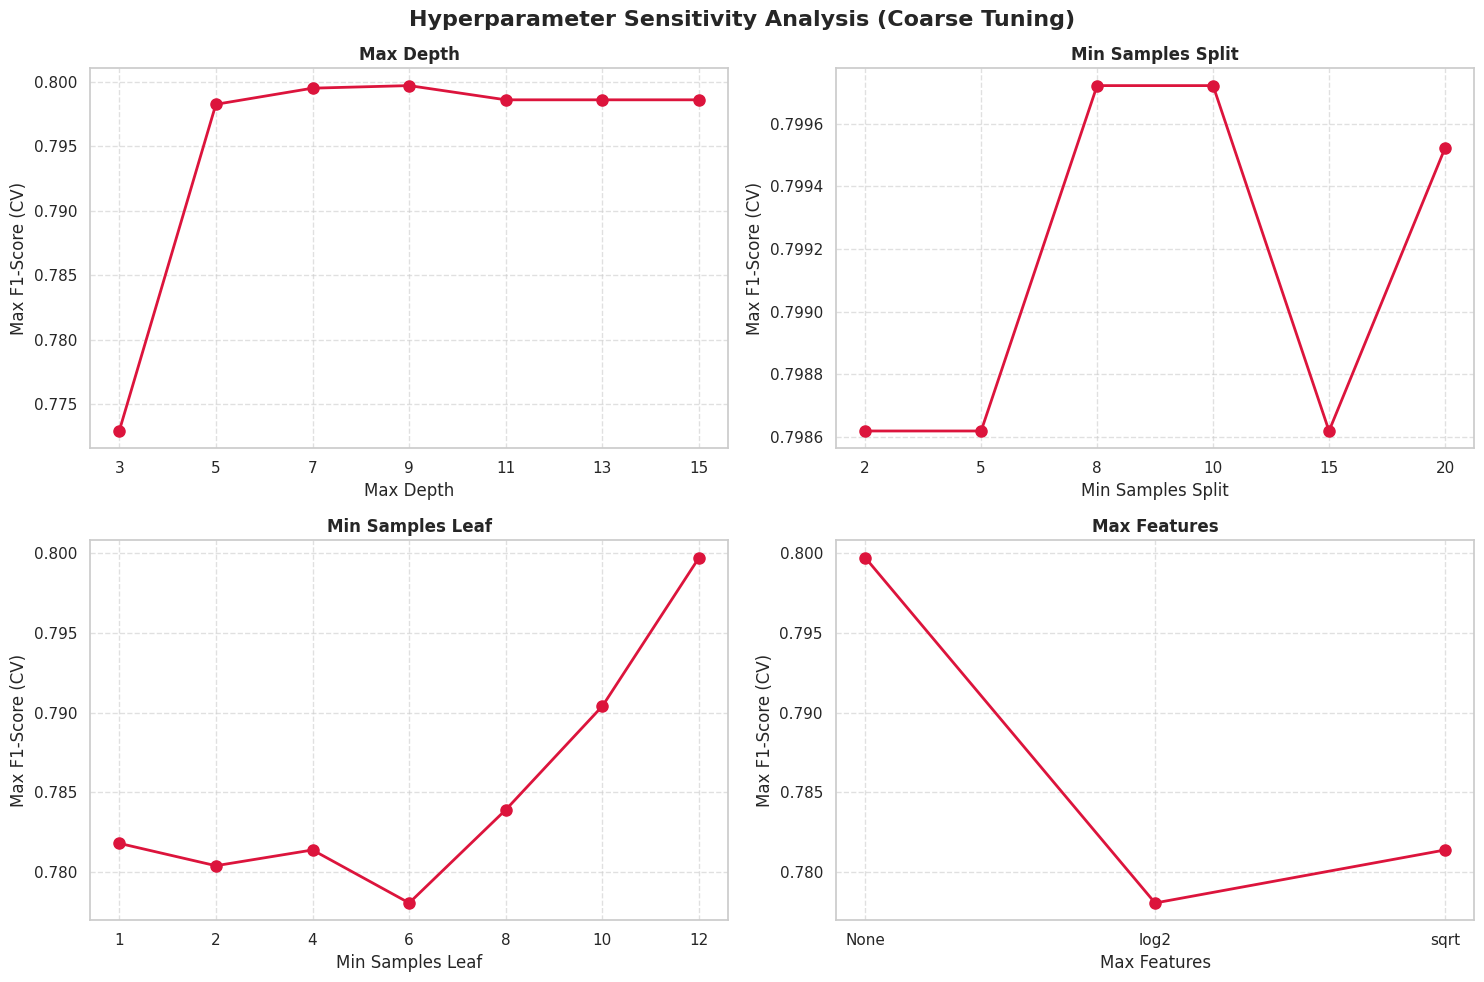

  STEP 2 — FINE TUNING (GRID SEARCH)
  Final Tuned Hyperparameters:
    max_depth             : 9
    max_features          : None
    min_samples_leaf      : 12
    min_samples_split     : 6

  Final F1-Score (CV=10) : 0.7997

  STEP 3 — THRESHOLD TUNING
    Thresh    F1-Score    Accuracy    Combined
  ---------------------------------------------
      0.25      0.8261      0.7826      0.8043
      0.26      0.8297      0.7880      0.8089
      0.31      0.8319      0.7935      0.8127
      0.32      0.8416      0.8098      0.8257
      0.37      0.8519      0.8261      0.8390

  → Optimal Classification Threshold : 0.37

  EVALUATION RESULTS (Threshold = 0.37)
  Accuracy             : 82.61%
  ROC-AUC              : 0.8873
  Sensitivity (Recall) : 0.9020
  Specificity          : 0.7317
-------------------------------------------------------
              precision    recall  f1-score   support

  No Disease       0.86      0.73      0.79        82
     Disease       0.81      0.90  

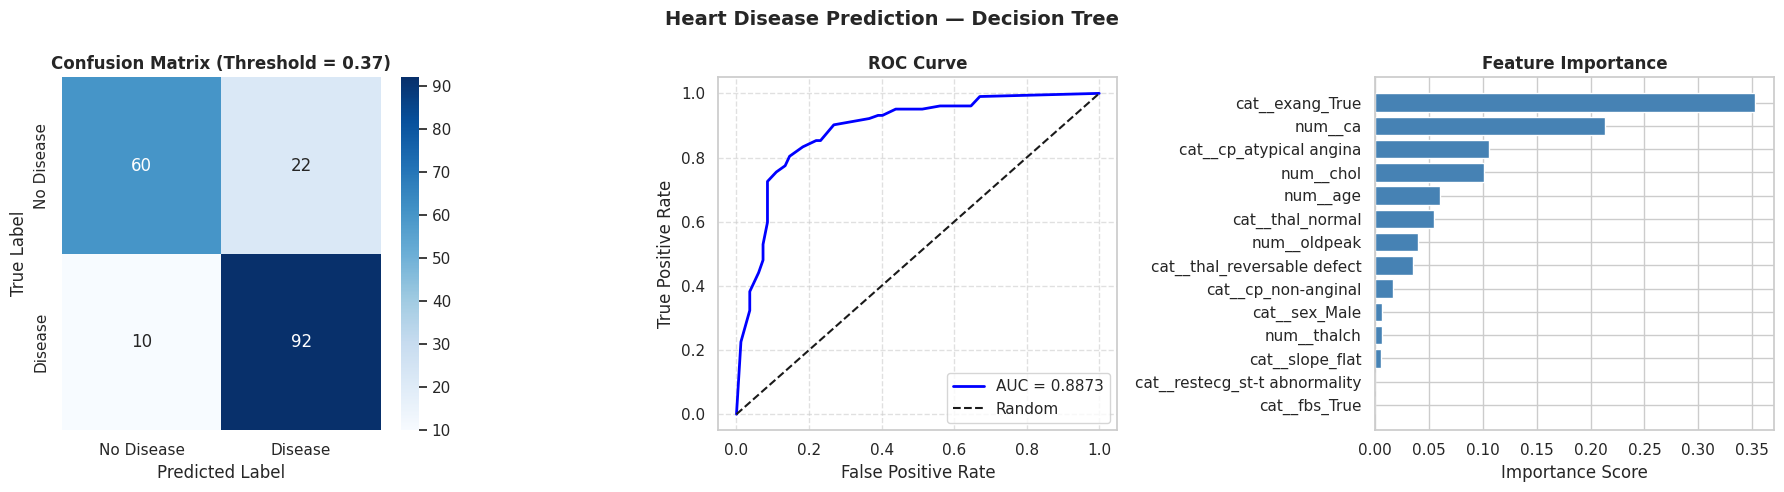

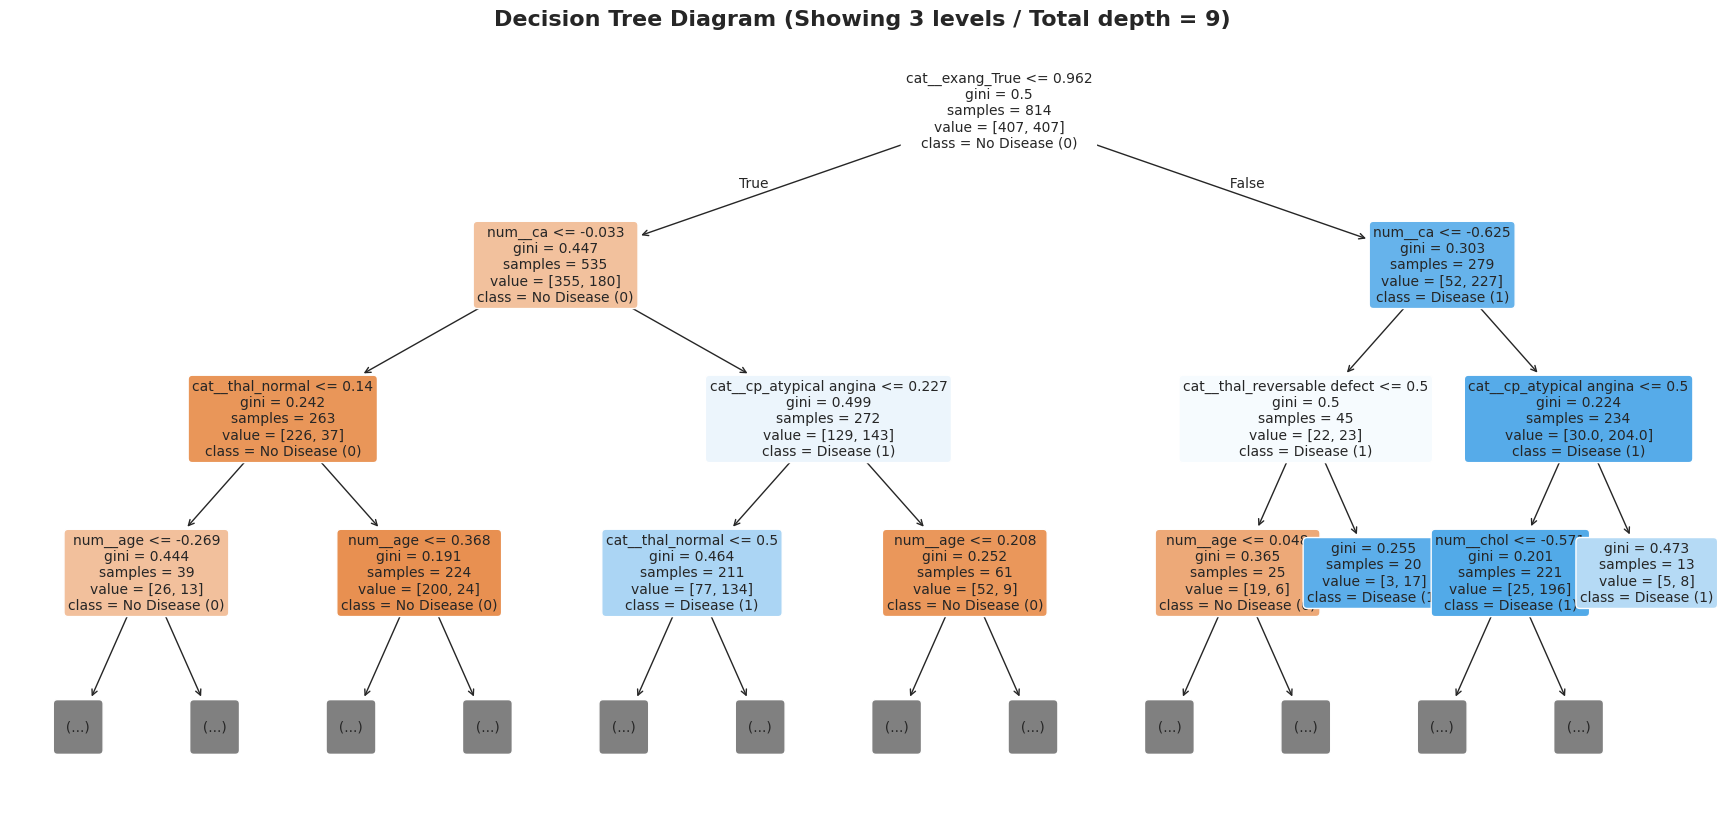


Model successfully saved to 'decision_tree_model.pkl'


In [ ]:
# =========================================================
# 1. IMPORT LIBRARIES
# =========================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve, f1_score
)
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
import time
import warnings
warnings.filterwarnings('ignore')
# =========================================================
# 2. LOAD DATA
# =========================================================
df_train = pd.read_csv('heart_train_cleaned.csv')
df_test  = pd.read_csv('heart_test_cleaned.csv')

X_train = df_train.drop(columns=['target'])
y_train = df_train['target']
X_test  = df_test.drop(columns=['target'])
y_test  = df_test['target']

# =========================================================
# 3. BASELINE EVALUATION — UNCONSTRAINED DECISION TREE
# =========================================================
dt_default = DecisionTreeClassifier(random_state=42)
dt_default.fit(X_train, y_train)

# Calculate baseline metrics for comparison
y_pred_baseline     = dt_default.predict(X_test)
y_proba_baseline    = dt_default.predict_proba(X_test)[:, 1]

cm_base             = confusion_matrix(y_test, y_pred_baseline)
TN_b, FP_b, FN_b, TP_b = cm_base.ravel()

acc_base            = accuracy_score(y_test, y_pred_baseline)
auc_base            = roc_auc_score(y_test, y_proba_baseline)
sensitivity_base    = TP_b / (TP_b + FN_b)
specificity_base    = TN_b / (TN_b + FP_b)
f1_base             = f1_score(y_test, y_pred_baseline)

print("=" * 55)
print("  BASELINE — UNCONSTRAINED DECISION TREE")
print("=" * 55)
print(f"  Train Accuracy       : {dt_default.score(X_train, y_train):.2%}")
print(f"  Test  Accuracy       : {acc_base:.2%}")
print(f"  ROC-AUC              : {auc_base:.4f}")
print(f"  Sensitivity (Recall) : {sensitivity_base:.4f}")
print(f"  Specificity          : {specificity_base:.4f}")
print(f"  F1-Score (Test)      : {f1_base:.4f}")
print("-" * 55)
print("  → Large Train/Test gap indicates Overfitting.")
print("    Tuning is required.")
print("=" * 55, "\n")

# =========================================================
# 4. COARSE TUNING — RANDOMIZED SEARCH
#    Goal: Quickly explore a wide parameter space.
#    Keep criterion='gini' and class_weight=None as default.
# =========================================================
print("=" * 55)
print("  STEP 1 — COARSE TUNING (RANDOMIZED SEARCH)")
print("=" * 55)
print("  Searching over a wide parameter space...")

start_time = time.time()

# Hyperparameter space for coarse search
param_dist_dt_coarse = {
    "max_depth":         [3, 5, 7, 9, 11, 13, 15, None],
    "max_features":      ["sqrt", "log2", None],
    "min_samples_split": [2, 5, 8, 10, 15, 20],
    "min_samples_leaf":  [1, 2, 4, 6, 8, 10, 12],
}

# RandomizedSearchCV: sample 200 random combinations to save time
rand_dt = RandomizedSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_distributions=param_dist_dt_coarse,
    n_iter=200,       # Number of random combinations
    cv=10,            # 10-fold CV for reliable estimation
    scoring="f1",
    n_jobs=-1,
    random_state=42
)

rand_dt.fit(X_train, y_train)
elapsed = round(time.time() - start_time, 2)

print(f"  Completed in {elapsed} seconds.")
print(f"\n  Best Hyperparameters:")
for k, v in rand_dt.best_params_.items():
    print(f"    {k:<22}: {v}")
print(f"\n  Best F1-Score (CV=10) : {rand_dt.best_score_:.4f}")
print("=" * 55, "\n")


# =========================================================
# HYPERPARAMETER SENSITIVITY ANALYSIS
# Visualize the impact of each hyperparameter on the
# maximum F1-Score achieved during the search.
# =========================================================
results_df = pd.DataFrame(rand_dt.cv_results_)
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()

params_to_plot = ['param_max_depth', 'param_min_samples_split',
                  'param_min_samples_leaf', 'param_max_features']
titles = ['Max Depth', 'Min Samples Split', 'Min Samples Leaf', 'Max Features']

for idx, param in enumerate(params_to_plot):
    temp_df = results_df.copy()
    temp_df[param] = temp_df[param].fillna('None_Value').astype(str)
    summary = temp_df.groupby(param)['mean_test_score'].max().reset_index()

    if param != 'param_max_features':
        summary = summary[summary[param] != 'None_Value']
        summary[param] = summary[param].astype(float)
        summary = summary.sort_values(by=param)
        x_values = summary[param].astype(int).astype(str)
    else:
        summary[param] = summary[param].replace('None_Value', 'None')
        x_values = summary[param]

    y_values = summary['mean_test_score']

    axes[idx].plot(x_values, y_values, marker='o', color='crimson',
                   linewidth=2, markersize=8)
    axes[idx].set_title(f'{titles[idx]}', fontweight='bold')
    axes[idx].set_xlabel(titles[idx])
    axes[idx].set_ylabel('Max F1-Score (CV)')
    axes[idx].grid(True, linestyle='--', alpha=0.6)

plt.suptitle('Hyperparameter Sensitivity Analysis (Coarse Tuning)',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# =========================================================
# 5. FINE TUNING — GRID SEARCH
#    Goal: Fine-tune in a narrow region around the best
#    parameters found in Coarse Tuning.
# =========================================================
print("=" * 55)
print("  STEP 2 — FINE TUNING (GRID SEARCH)")
print("=" * 55)

best_dt = rand_dt.best_params_

# Handle max_depth = None (unconstrained tree)
d_dt  = best_dt["max_depth"] or 15
ms_dt = best_dt["min_samples_split"]
ml_dt = best_dt["min_samples_leaf"]

# Narrow grid: search ±2 and +4 around the best values.
# Use set{} to automatically remove duplicates before sorting.
param_grid_dt_fine = {
    "max_features":      [best_dt["max_features"]],
    "max_depth":         sorted({max(2, d_dt-2),  d_dt, d_dt+2,  d_dt+4}),
    "min_samples_split": sorted({max(2, ms_dt-2), ms_dt, ms_dt+2, ms_dt+4}),
    "min_samples_leaf":  sorted({max(1, ml_dt-2), ml_dt, ml_dt+2, ml_dt+4}),
}

grid_dt = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid_dt_fine,
    cv=10,
    scoring="f1",
    n_jobs=-1
)

grid_dt.fit(X_train, y_train)
dt_tuned = grid_dt.best_estimator_

print(f"  Final Tuned Hyperparameters:")
for k, v in grid_dt.best_params_.items():
    print(f"    {k:<22}: {v}")
print(f"\n  Final F1-Score (CV=10) : {grid_dt.best_score_:.4f}")
print("=" * 55, "\n")

# =========================================================
# 6. THRESHOLD TUNING — OPTIMAL CLASSIFICATION THRESHOLD
#    Iterate thresholds from 0.25 to 0.70, optimizing a
#    combined F1-Score and Accuracy metric (50/50).
# =========================================================
print("=" * 55)
print("  STEP 3 — THRESHOLD TUNING")
print("=" * 55)
print(f"  {'Thresh':>8}  {'F1-Score':>10}  {'Accuracy':>10}  {'Combined':>10}")
print("  " + "-" * 45)

y_pred_proba  = dt_tuned.predict_proba(X_test)[:, 1]
best_thresh   = 0.5
best_combined = 0.0
weight_f1     = 0.5   # Weights: 50% F1, 50% Accuracy

for thresh in np.arange(0.25, 0.70, 0.01):
    y_tmp = (y_pred_proba >= thresh).astype(int)

    # Skip if model predicts only one class
    if len(np.unique(y_tmp)) < 2:
        continue

    f        = f1_score(y_test, y_tmp)
    a        = accuracy_score(y_test, y_tmp)
    combined = weight_f1 * f + (1 - weight_f1) * a

    # Print only when a new record is set
    if combined > best_combined:
        best_combined = combined
        best_thresh   = thresh
        print(f"  {thresh:>8.2f}  {f:>10.4f}  {a:>10.4f}  {combined:>10.4f}")

y_pred_final = (y_pred_proba >= best_thresh).astype(int)
print(f"\n  → Optimal Classification Threshold : {best_thresh:.2f}")
print("=" * 55, "\n")

# =========================================================
# 7. MODEL EVALUATION ON TEST SET
# =========================================================
cm = confusion_matrix(y_test, y_pred_final)
TN, FP, FN, TP = cm.ravel()

accuracy    = accuracy_score(y_test, y_pred_final)
auc_score   = roc_auc_score(y_test, y_pred_proba)
sensitivity = TP / (TP + FN)
specificity = TN / (TN + FP)

print("=" * 55)
print(f"  EVALUATION RESULTS (Threshold = {best_thresh:.2f})")
print("=" * 55)
print(f"  Accuracy             : {accuracy:.2%}")
print(f"  ROC-AUC              : {auc_score:.4f}")
print(f"  Sensitivity (Recall) : {sensitivity:.4f}")
print(f"  Specificity          : {specificity:.4f}")
print("-" * 55)
print(classification_report(y_test, y_pred_final,
                             target_names=['No Disease', 'Disease']))
print("=" * 55, "\n")

# ---------------------------------------------------------
# BASELINE VS. TUNED COMPARISON
# ---------------------------------------------------------
delta_acc  = accuracy    - acc_base
delta_auc  = auc_score   - auc_base
delta_sens = sensitivity - sensitivity_base
delta_spec = specificity - specificity_base
delta_f1   = f1_score(y_test, y_pred_final) - f1_base

def fmt_delta(v):
    """Format delta: add '+' if positive, keep '-' if negative."""
    return f"+{v:.4f}" if v >= 0 else f"{v:.4f}"

print("=" * 55)
print("  BASELINE VS. TUNED COMPARISON")
print("=" * 55)
print(f"  {'Metric':<24} {'Baseline':>8}  {'Tuned':>8}  {'Δ':>8}")
print("  " + "-" * 51)
print(f"  {'Accuracy':<24} {acc_base:>8.2%}  {accuracy:>8.2%}  {fmt_delta(delta_acc):>8}")
print(f"  {'ROC-AUC':<24} {auc_base:>8.4f}  {auc_score:>8.4f}  {fmt_delta(delta_auc):>8}")
print(f"  {'Sensitivity (Recall)':<24} {sensitivity_base:>8.4f}  {sensitivity:>8.4f}  {fmt_delta(delta_sens):>8}")
print(f"  {'Specificity':<24} {specificity_base:>8.4f}  {specificity:>8.4f}  {fmt_delta(delta_spec):>8}")
print(f"  {'F1-Score (Test)':<24} {f1_base:>8.4f}  {f1_score(y_test, y_pred_final):>8.4f}  {fmt_delta(delta_f1):>8}")
print("=" * 55, "\n")

# =========================================================
# 8. VISUALIZE RESULTS
#    Includes 3 plots: Confusion Matrix, ROC Curve,
#    and Feature Importance of the tuned model.
# =========================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Plot 1: Confusion Matrix ---
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
axes[0].set_title(f'Confusion Matrix (Threshold = {best_thresh:.2f})',
                  fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# --- Plot 2: ROC Curve ---
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
axes[1].plot(fpr, tpr, color='blue', lw=2, label=f'AUC = {auc_score:.4f}')
axes[1].plot([0, 1], [0, 1], 'k--', label='Random')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].grid(True, linestyle='--', alpha=0.6)

# --- Plot 3: Feature Importance ---
# Show only features with actual contribution (importance > 0)
importance = pd.Series(dt_tuned.feature_importances_, index=X_train.columns)
importance = importance[importance > 0].sort_values(ascending=False)

axes[2].barh(importance.index[::-1], importance.values[::-1], color='steelblue')
axes[2].set_title('Feature Importance', fontweight='bold')
axes[2].set_xlabel('Importance Score')

plt.suptitle('Heart Disease Prediction — Decision Tree',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# =========================================================
# 9. DECISION TREE VISUALIZATION
#    Show the first 3 levels for readability.
# =========================================================
plt.figure(figsize=(22, 10))
plot_tree(
    dt_tuned,
    feature_names=X_train.columns.tolist(),
    class_names=["No Disease (0)", "Disease (1)"],
    filled=True,
    rounded=True,
    max_depth=3,      # Limit to 3 levels to avoid clutter
    fontsize=10
)
plt.title(
    f"Decision Tree Diagram (Showing 3 levels / Total depth = {dt_tuned.max_depth})",
    fontsize=16, fontweight='bold'
)
plt.show()

# =========================================================
# 10. SAVE MODEL
# =========================================================
joblib.dump(dt_tuned, 'decision_tree_model.pkl')
print("\nModel successfully saved to 'decision_tree_model.pkl'")

Kích thước tập Train: (814, 15) | Tập Test: (184, 15)
--- KẾT QUẢ ĐÁNH GIÁ LOGISTIC REGRESSION ---
Accuracy : 0.8369565217391305
ROC-AUC  : 0.8958632233381157

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.79      0.81        82
           1       0.84      0.87      0.86       102

    accuracy                           0.84       184
   macro avg       0.84      0.83      0.83       184
weighted avg       0.84      0.84      0.84       184


Confusion Matrix:
 [[65 17]
 [13 89]]


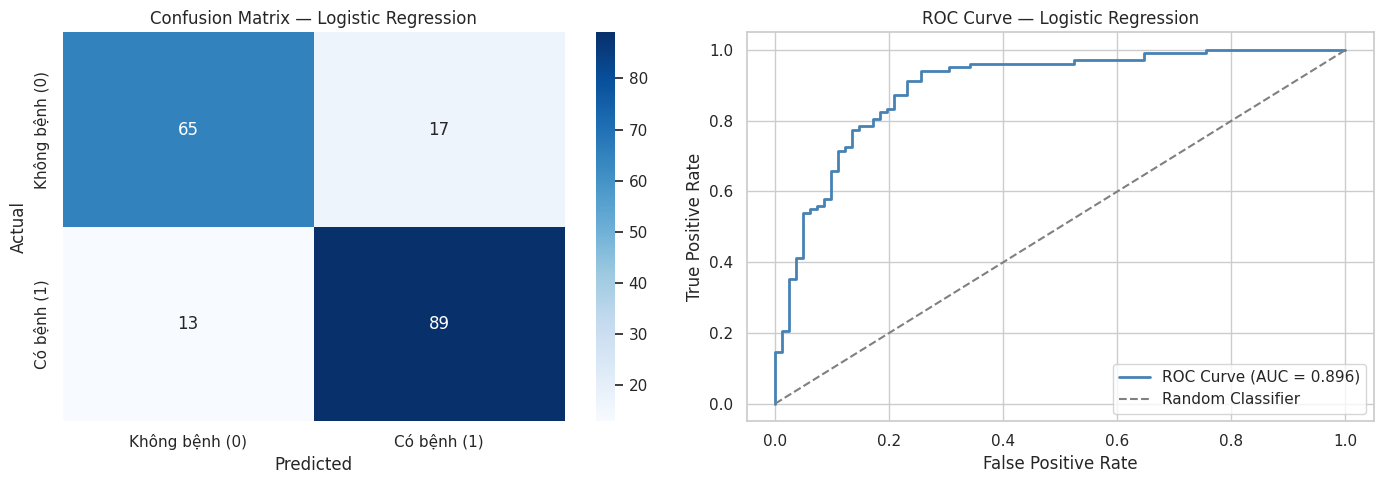


Model successfully saved to 'logistic_regression_model.pkl'


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve
)

# =========================================================
# 1. ĐỌC DỮ LIỆU ĐÃ PREPROCESSING
# =========================================================
df_train = pd.read_csv('heart_train_cleaned.csv')
df_test  = pd.read_csv('heart_test_cleaned.csv')

X_train = df_train.drop(columns=['target'])
y_train = df_train['target']
X_test  = df_test.drop(columns=['target'])
y_test  = df_test['target']

print(f"Kích thước tập Train: {X_train.shape} | Tập Test: {X_test.shape}")

# =========================================================
# 2. KHỞI TẠO VÀ HUẤN LUYỆN MODEL
# =========================================================
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

# =========================================================
# 3. DỰ ĐOÁN VÀ ĐÁNH GIÁ TRÊN TẬP TEST
# =========================================================
y_pred      = lr_model.predict(X_test)
y_pred_prob = lr_model.predict_proba(X_test)[:, 1]  # xác suất class 1 (có bệnh)

print("--- KẾT QUẢ ĐÁNH GIÁ LOGISTIC REGRESSION ---")
print("Accuracy :", accuracy_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_pred_prob))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

# =========================================================
# 4. TRỰC QUAN HÓA CONFUSION MATRIX
# =========================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Không bệnh (0)', 'Có bệnh (1)'],
            yticklabels=['Không bệnh (0)', 'Có bệnh (1)'],
            ax=axes[0])
axes[0].set_title('Confusion Matrix — Logistic Regression')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# --- ROC Curve ---
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
auc_score   = roc_auc_score(y_test, y_pred_prob)

axes[1].plot(fpr, tpr, color='steelblue', lw=2,
             label=f'ROC Curve (AUC = {auc_score:.3f})')
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Classifier')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve — Logistic Regression')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

joblib.dump(lr_model, 'logistic_regression_model.pkl')
print("\nModel successfully saved to 'logistic_regression_model.pkl'")

Train: (814, 15) | Test: (184, 15)
Bộ tham số tốt nhất: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Model tốt nhất: RandomForestClassifier(max_depth=20, n_estimators=300, random_state=42)

KẾT QUẢ ĐÁNH GIÁ
Accuracy:             87.5%
ROC-AUC:              0.9189
Sensitivity (Recall): 0.9216
Specificity:          0.8171

Classification Report:
              precision    recall  f1-score   support

  Không bệnh       0.89      0.82      0.85        82
     Có bệnh       0.86      0.92      0.89       102

    accuracy                           0.88       184
   macro avg       0.88      0.87      0.87       184
weighted avg       0.88      0.88      0.87       184


K-FOLD CROSS-VALIDATION (K=10)
Các mức Accuracy từng Fold: [0.84146341 0.80487805 0.84146341 0.84146341 0.79012346 0.79012346
 0.81481481 0.80246914 0.91358025 0.90123457]
Accuracy trung bình (Mean): 83.42%
Độ lệch chuẩn (Std Dev):    4.13%


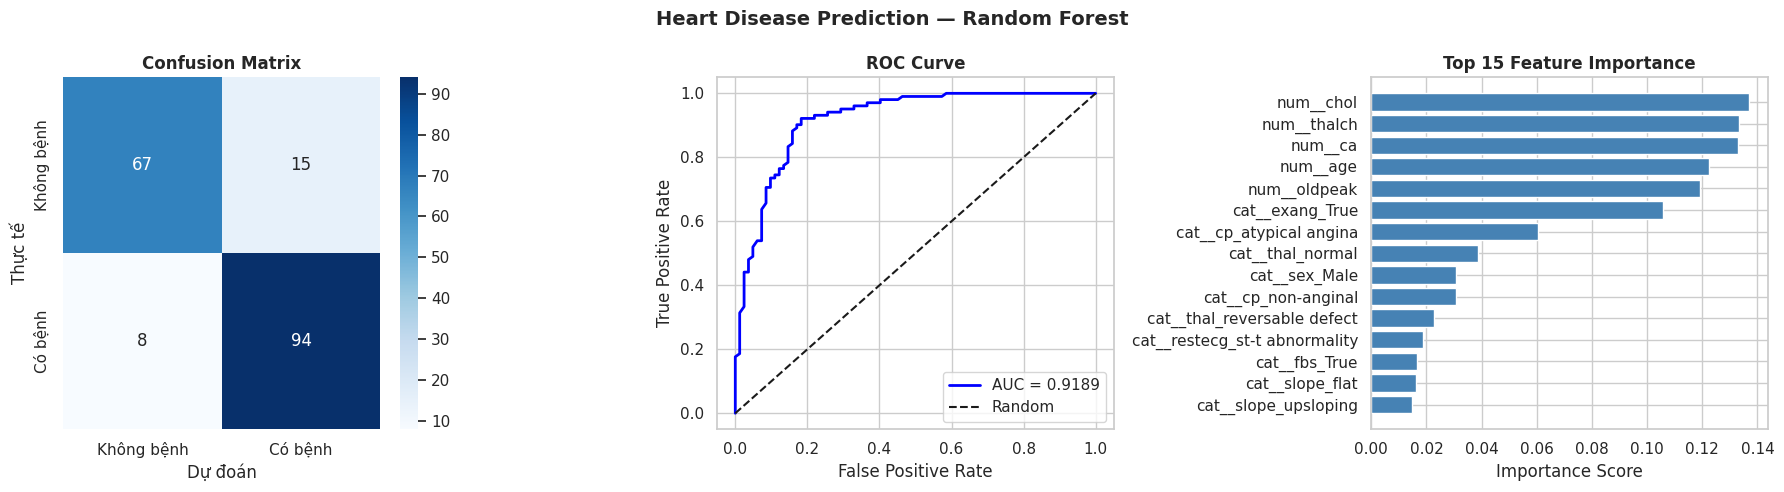

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve
)
from sklearn.model_selection import GridSearchCV, cross_val_score

# LOAD PREPROCESSED DATA

df_train = pd.read_csv('heart_train_cleaned.csv')
df_test  = pd.read_csv('heart_test_cleaned.csv')

X_train = df_train.drop(columns=['target'])
y_train = df_train['target']

X_test = df_test.drop(columns=['target'])
y_test = df_test['target']

print(f"Train: {X_train.shape} | Test: {X_test.shape}")

# HYPERPARAMETER TUNING
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=10,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train) # Train model

best_params = grid_search.best_params_
rf_model    = grid_search.best_estimator_

print(f"Bộ tham số tốt nhất: {best_params}")
print(f"Model tốt nhất: {rf_model}")

joblib.dump(rf_model, 'rf_model.pkl') # Save file

# PREDICT & EVALUATE
y_pred       = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]

cm = confusion_matrix(y_test, y_pred)
TN, FP, FN, TP = cm.ravel()

accuracy    = accuracy_score(y_test, y_pred)
auc         = roc_auc_score(y_test, y_pred_proba)
sensitivity = TP / (TP + FN)
specificity = TN / (TN + FP)

print(f"\n{'='*45}")
print("KẾT QUẢ ĐÁNH GIÁ")
print(f"{'='*45}")
print(f"Accuracy:             {round(accuracy * 100, 2)}%")
print(f"ROC-AUC:              {round(auc, 4)}")
print(f"Sensitivity (Recall): {round(sensitivity, 4)}")
print(f"Specificity:          {round(specificity, 4)}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred,
      target_names=['Không bệnh', 'Có bệnh']))

cv_scores = cross_val_score(rf_model, X_train, y_train, cv=10, scoring='accuracy')

print(f"\n{'='*45}")
print("K-FOLD CROSS-VALIDATION (K=10)")
print(f"{'='*45}")
print(f"Các mức Accuracy từng Fold: {cv_scores}")
print(f"Accuracy trung bình (Mean): {round(cv_scores.mean() * 100, 2)}%")
print(f"Độ lệch chuẩn (Std Dev):    {round(cv_scores.std() * 100, 2)}%")

# VISUALIZATION

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Confusion Matrix ---
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Không bệnh', 'Có bệnh'],
            yticklabels=['Không bệnh', 'Có bệnh'])
axes[0].set_title('Confusion Matrix', fontweight='bold')
axes[0].set_ylabel('Thực tế')
axes[0].set_xlabel('Dự đoán')

# --- ROC Curve ---
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
axes[1].plot(fpr, tpr, color='blue', lw=2,
             label=f'AUC = {round(auc, 4)}')
axes[1].plot([0, 1], [0, 1], 'k--', label='Random')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontweight='bold')
axes[1].legend()

# --- Feature Importance ---
feat_imp = pd.Series(rf_model.feature_importances_,
                     index=X_train.columns) \
             .sort_values(ascending=False).head(15)

axes[2].barh(feat_imp.index[::-1], feat_imp.values[::-1], color='steelblue')
axes[2].set_title('Top 15 Feature Importance', fontweight='bold')
axes[2].set_xlabel('Importance Score')

plt.suptitle('Heart Disease Prediction — Random Forest',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('rf_evaluation.png', bbox_inches='tight', dpi=150)
plt.show()
plt.close()